# Machine Learning Project - Password Strength Classifiers

Simone Piras 70/90/00539, Giovanni Presenti 70/90/00556, Alessia Tiddia 70/90/00501

#### Introduction 
This work aims to compare different classifiers for password strength prediction using a dataset of passwords with their respective strength labels.

#### Initial operations

In [71]:
import pandas as pd
import os

# Constants to define the number of training and testing samples
N_TRAIN = 1000
N_TEST =  100000


# Load the dataset
dirname = os.getcwd()
filename = os.path.join(dirname, "Dataset/data.csv")
data = pd.read_csv(filename, on_bad_lines="skip")
#N_TEST =  len(data) - N_TRAIN

#### Feature extraction

In [72]:
import numpy as np


def feature_extractor(data, n_train, n_test):
    """
    Extracts and normalizes password features for training and testing from a given dataset.
    Parameters:
        data (pandas.DataFrame): The input DataFrame containing 'password' and 'strength' columns.
        n_train (int): Number of samples to use for the training set.
        n_test (int): Number of samples to use for the test set.
    Returns:
        tuple: A tuple containing:
            - xtr (np.ndarray): Training feature matrix of shape (n_train, 4) with columns:
                [password length, normalized digit count, normalized symbol count, normalized uppercase count].
            - ytr (np.ndarray): Training target array of shape (n_train,).
            - xts (np.ndarray): Test feature matrix of shape (n_test, 4) with the same columns as xtr.
            - yts (np.ndarray): Test target array of shape (n_test,).
    Notes:
        - The dataset is shuffled before splitting.
        - Feature normalization is performed by dividing counts by password length (with division by zero avoided).
    """
    # Shuffle the dataset
    data_shuffled = data.sample(frac=1)

    # Ensure the 'password' column is treated as string
    data_shuffled["password"] = data_shuffled["password"].astype(str)

    # Extract features
    pass_length_train = data_shuffled["password"].str.len().head(N_TRAIN).values
    digits_train = (data_shuffled["password"].head(N_TRAIN).apply(lambda x: len([c for c in x if c.isdigit()])).values)
    symbols_train = (data_shuffled["password"].head(N_TRAIN).apply(lambda x: len([c for c in x if not c.isalnum()])).values)
    upper_train = (data_shuffled["password"].head(N_TRAIN).apply(lambda x: len([c for c in x if c.isupper()])).values)
    lower_train = (data_shuffled["password"].head(N_TRAIN).apply(lambda x: len([c for c in x if c.islower()])).values)
    unique_chars_train = data_shuffled["password"].head(N_TRAIN).apply(lambda x: len(set(x))).values

    pass_length_test = data_shuffled["password"].str.len().tail(N_TEST).values
    digits_test = (data_shuffled["password"].tail(N_TEST).apply(lambda x: len([c for c in x if c.isdigit()])).values)
    symbols_test = (data_shuffled["password"].tail(N_TEST).apply(lambda x: len([c for c in x if not c.isalnum()])).values)
    upper_test = (data_shuffled["password"].tail(N_TEST).apply(lambda x: len([c for c in x if c.isupper()])).values)
    lower_test = (data_shuffled["password"].tail(N_TEST).apply(lambda x: len([c for c in x if c.islower()])).values)
    unique_chars_test = data_shuffled["password"].tail(N_TEST).apply(lambda x: len(set(x))).values

    # Normalize features by password length (avoid division by zero)
    digits_train_norm = digits_train / np.where(pass_length_train == 0, 1, pass_length_train)
    symbols_train_norm = symbols_train / np.where(pass_length_train == 0, 1, pass_length_train)
    upper_train_norm = upper_train / np.where(pass_length_train == 0, 1, pass_length_train)
    lower_train_norm = lower_train / np.where(pass_length_train == 0, 1, pass_length_train)
    unique_ratio_train = unique_chars_train / np.where(pass_length_train == 0, 1, pass_length_train)

    digits_test_norm = digits_test / np.where(pass_length_test == 0, 1, pass_length_test)
    symbols_test_norm = symbols_test / np.where(pass_length_test == 0, 1, pass_length_test)
    upper_test_norm = upper_test /  np.where(pass_length_test == 0, 1, pass_length_test)
    lower_test_norm = lower_test /  np.where(pass_length_test == 0, 1, pass_length_test)
    unique_ratio_test = unique_chars_test / np.where(pass_length_test == 0, 1, pass_length_test)


    # Split the dataset into features and target variable
    xtr = np.array([pass_length_train, digits_train_norm, symbols_train_norm, upper_train_norm, lower_train_norm, unique_ratio_train]).T
    ytr = data_shuffled["strength"].head(n_train).values

    xts = np.array([pass_length_test, digits_test_norm, symbols_test_norm, upper_test_norm, lower_test_norm, unique_ratio_test]).T
    yts = data_shuffled["strength"].tail(n_test).values

    return (xtr, ytr, xts, yts, data_shuffled)

# Extract features from the dataset
xtr, ytr, xts, yts, data_shuffled = feature_extractor(data, N_TRAIN, N_TEST)

#### Display Train and Test subsets by password length

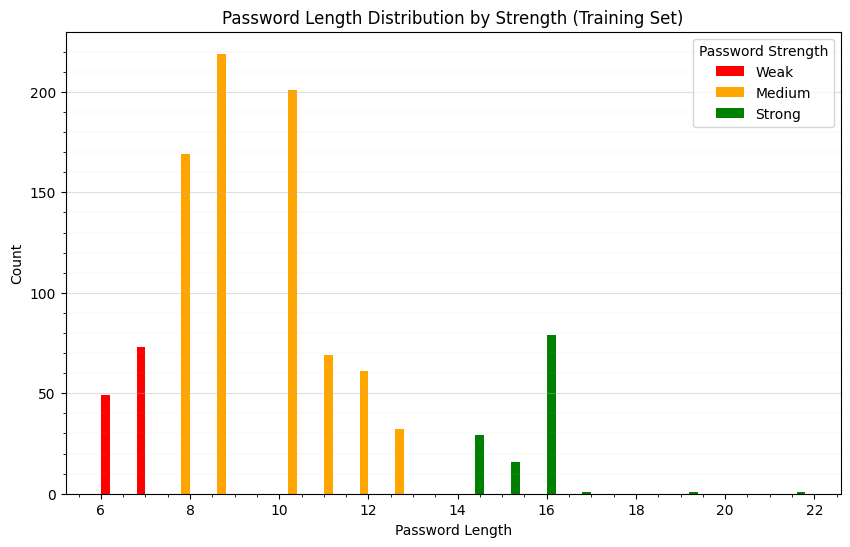

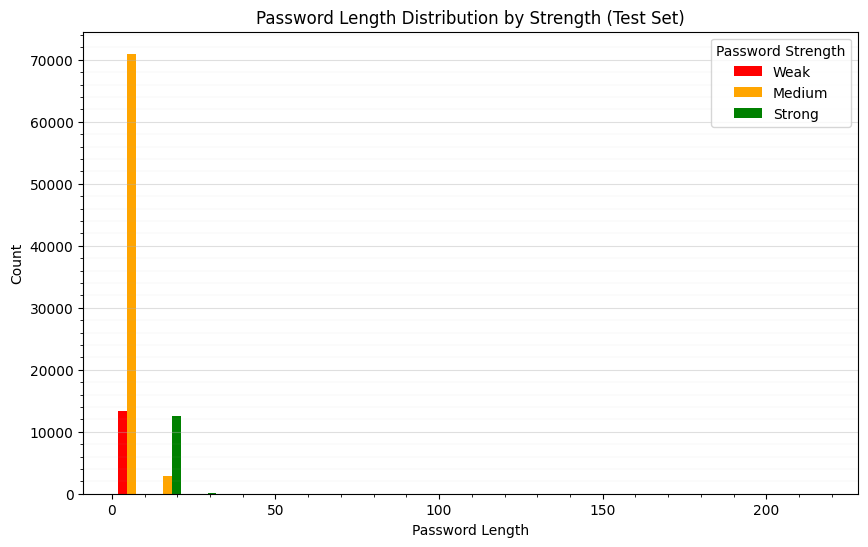

In [73]:
import matplotlib.pyplot as plt


def plot_dataset(x, y, title, bins=20):
    """
    Plots the distribution of password lengths grouped by their strength categories.
    Parameters:
        x (np.ndarray): 2D array where the first column contains password lengths.
        y (np.ndarray): 1D array of class labels corresponding to password strength for each sample in x.
        title (str, optional): Title of the plot.
        bins (int, optional): Number of bins to use for the histogram. Default is 20.
        
    Displays:
        A bar plot showing the distribution of password lengths for each strength class, with different colors and a legend.
    """
    plt.figure(figsize=(10, 6))
    classes = np.unique(y) 
    colors = ["red", "orange", "green", "blue", "purple", "cyan", "magenta"]
    all_lengths = x[:, 0]
    bin_edges = np.histogram_bin_edges(all_lengths, bins=bins)
    width = (bin_edges[1] - bin_edges[0]) / (len(classes) + 1)
    legend_names = ["Weak", "Medium", "Strong"]
    for i, k in enumerate(classes):
        lengths = x[y == k, 0]
        hist, _ = np.histogram(lengths, bins=bin_edges)
        plt.bar(
            bin_edges[:-1] + i * width,
            hist,
            width=width,
            color=colors[i % len(colors)],
            align="edge",
            label=legend_names[i],
        )

    plt.xlabel("Password Length")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend(title="Password Strength")
    plt.grid(axis="y", alpha=0.4)
    plt.minorticks_on()  # Enable minor ticks
    plt.grid(which="minor", axis="y", alpha=0.2, linewidth=0.3)  # Minor grid
    plt.show()

# Plot the distributions of password lengths for training and test sets
plot_dataset(xtr, ytr, title="Password Length Distribution by Strength (Training Set)")
plot_dataset(xts, yts, title="Password Length Distribution by Strength (Test Set)")

#### Classifiers definition

In [74]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

# Define the classifiers with their parameters
KNN_clf = KNeighborsClassifier(n_neighbors=5)
SVM_clf = SVC(kernel="rbf")
DT_clf = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=0)
#DT_reg = DecisionTreeRegressor()
GNB_clf = GaussianNB()
SGD_reg = SGDClassifier(loss="hinge", penalty="l2")

# List of classifiers to be trained and tested
#clfs = [KNN_clf, SVM_clf, DT_clf, DT_reg, GNB_clf, SGD_reg]
clfs = [KNN_clf, SVM_clf, DT_clf, GNB_clf, SGD_reg]

#### Classifiers training and evaluation



---		KNeighborsClassifier		---

	Training time:	 0.0018 seconds
	Prediction time: 6.1821 seconds
	Accuracy score:	 1.0000

              precision    recall  f1-score   support

        Weak       1.00      1.00      1.00     13356
      Medium       1.00      1.00      1.00     73919
      Strong       1.00      1.00      1.00     12725

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000



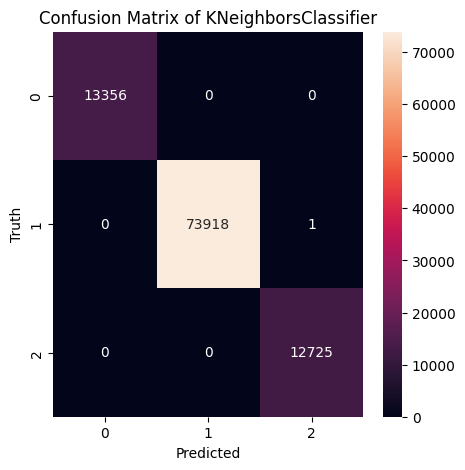



---		SVC		---

	Training time:	 0.0093 seconds
	Prediction time: 2.0559 seconds
	Accuracy score:	 0.9999

              precision    recall  f1-score   support

        Weak       1.00      1.00      1.00     13356
      Medium       1.00      1.00      1.00     73919
      Strong       1.00      1.00      1.00     12725

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000



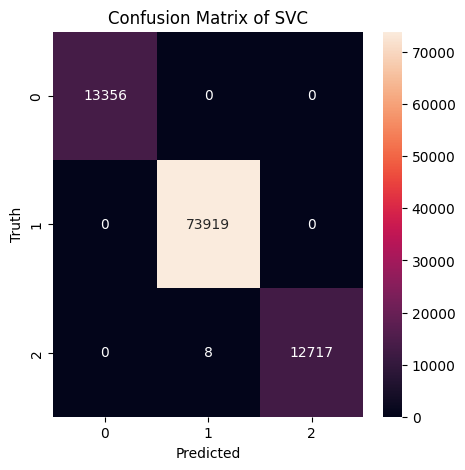



---		DecisionTreeClassifier		---

	Training time:	 0.0017 seconds
	Prediction time: 0.0062 seconds
	Accuracy score:	 1.0000

              precision    recall  f1-score   support

        Weak       1.00      1.00      1.00     13356
      Medium       1.00      1.00      1.00     73919
      Strong       1.00      1.00      1.00     12725

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000



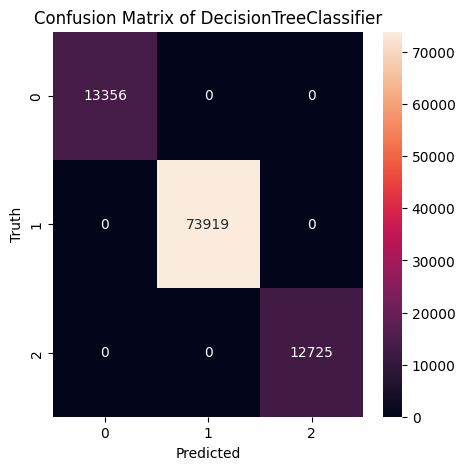



---		GaussianNB		---

	Training time:	 0.0018 seconds
	Prediction time: 0.0235 seconds
	Accuracy score:	 0.9768

              precision    recall  f1-score   support

        Weak       0.98      0.94      0.96     13356
      Medium       0.98      0.98      0.98     73919
      Strong       0.93      0.98      0.95     12725

    accuracy                           0.98    100000
   macro avg       0.97      0.97      0.96    100000
weighted avg       0.98      0.98      0.98    100000



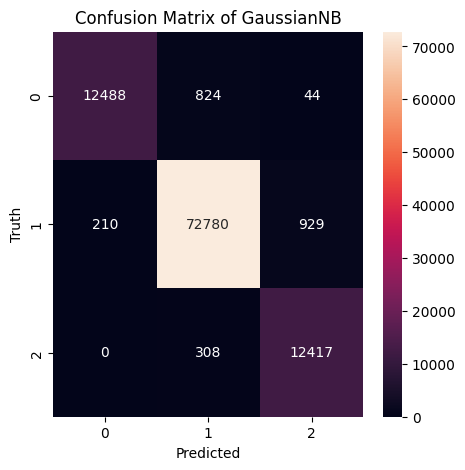



---		SGDClassifier		---

	Training time:	 0.0074 seconds
	Prediction time: 0.0068 seconds
	Accuracy score:	 0.9890

              precision    recall  f1-score   support

        Weak       0.99      1.00      0.99     13356
      Medium       0.99      1.00      0.99     73919
      Strong       0.99      0.93      0.96     12725

    accuracy                           0.99    100000
   macro avg       0.99      0.98      0.98    100000
weighted avg       0.99      0.99      0.99    100000



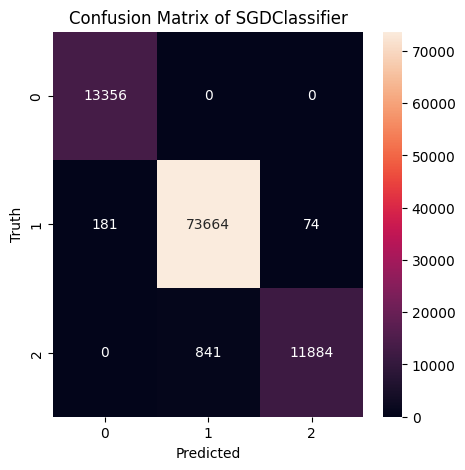

In [75]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, classification_report
import time

def plot_confusion_matrix(y_test, y_pred, classifier_name):
    """
    Plots the confusion matrix for a given set of true and predicted labels using a heatmap.

    Args:
        y_test (array-like): True labels of the test dataset.
        y_pred (array-like): Predicted labels from the classifier.
        classifier_name (str): Name of the classifier to display in the plot title.

    Returns:
        None: Displays the confusion matrix plot.
    """
    plt.figure(figsize=(5, 5))
    plt.title("Confusion Matrix of " + classifier_name)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("Truth")
    plt.show()


# Fit each classifier, make predictions, and evaluate performance
for clf in clfs:

    print("\n")
    print(f"---\t\t{clf.__class__.__name__}\t\t---\n")
    tic = time.perf_counter()
    clf.fit(xtr, ytr)
    toc = time.perf_counter()
    print(f"\tTraining time:\t {toc-tic:.4f} seconds")

    tic = time.perf_counter()
    predictions = clf.predict(xts)
    toc = time.perf_counter()
    print(f"\tPrediction time: {toc-tic:.4f} seconds")

    print(f"\tAccuracy score:\t {accuracy_score(yts, predictions):.4f}\n")
    print(classification_report(yts, predictions, target_names=["Weak", "Medium", "Strong"]))
    plot_confusion_matrix(yts, predictions, clf.__class__.__name__)
   

#### Features importance evaluation

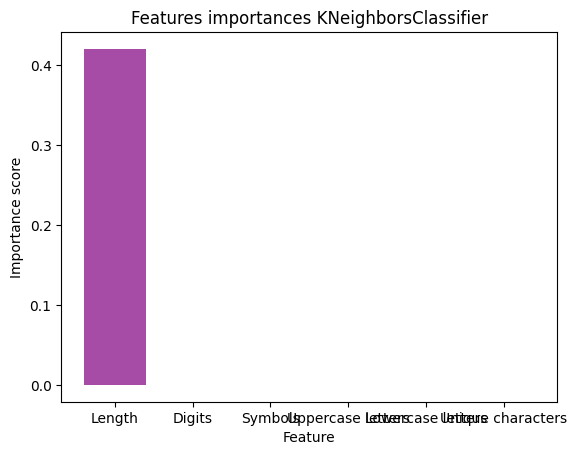

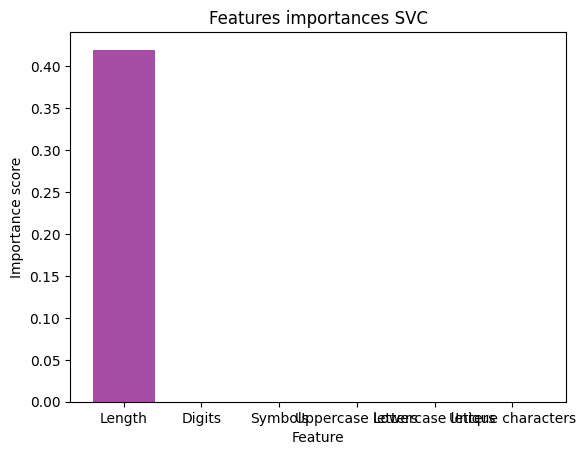

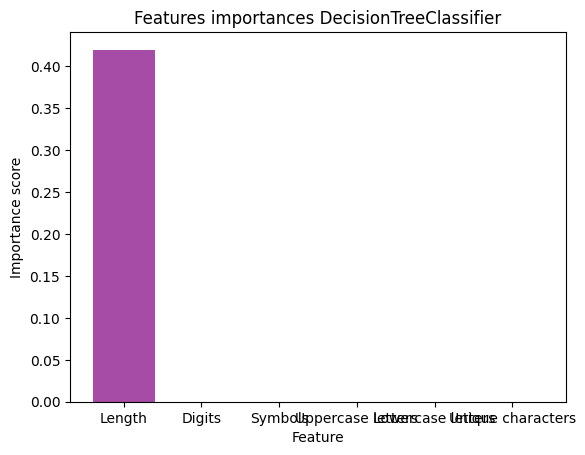

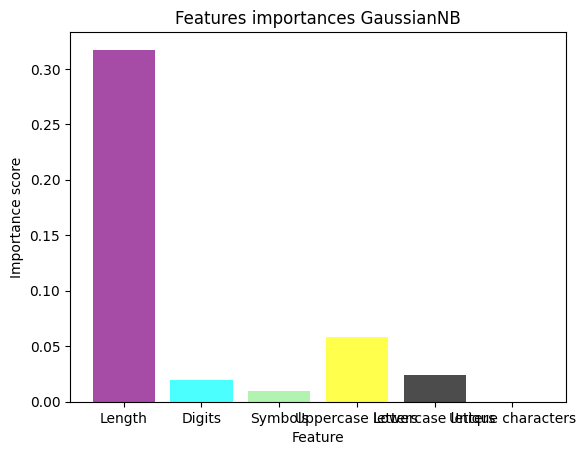

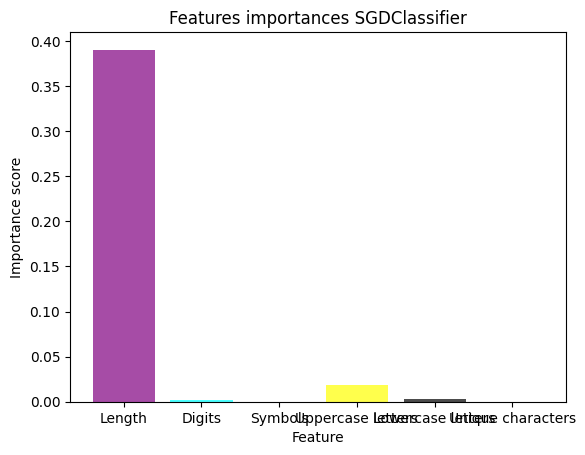

In [76]:
from sklearn.inspection import permutation_importance

def feature_importance_histogram(importances, feature_names=None, title=None):
    """
    Plots a histogram of feature importances.
    Parameters
    ----------
    importances: list or array-like
        The importance scores for each feature.
    feature_names: list of str, optional
        Names of the features to use as x-axis labels.
    title : str, optional
        The title of the plot.
    """
    colors = ["purple", "cyan", "lightgreen", "yellow", "black", "red", "blue", "orange"]
    n_features = len(importances)
    if feature_names is None:
        feature_names = [f"Feature {i}" for i in range(n_features)]

    plt.bar(
        range(n_features),
        importances,
        tick_label=feature_names,
        color=colors[:n_features],
        linewidth=1.2,
        alpha=0.7,
    )
    plt.xlabel("Feature")
    plt.ylabel("Importance score")
    plt.title(title)
    plt.show()

# Calculate and plot feature importances for each classifier
for clf in clfs:
    results = permutation_importance(clf, xts, yts, n_repeats=10, random_state=0)
    importances = results.importances_mean

    feature_names=["Length", "Digits", "Symbols", "Uppercase letters", "Lowercase letters", "Unique characters"]
    feature_importance_histogram(importances, feature_names, title=f"Features importances {clf.__class__.__name__}")

#### Test password length

In [77]:
# Split the dataset into features and target variable
xtr = np.array([(data_shuffled["password"].str.len().head(N_TRAIN).values)]).T
ytr = data_shuffled["strength"].head(N_TRAIN).values

xts = np.array([(data_shuffled["password"].str.len().tail(N_TEST).values)]).T
yts = data_shuffled["strength"].tail(N_TEST).values

for clf in clfs:

    print("\n")
    print(f"---\t\t{clf.__class__.__name__}\t\t---\n")
    tic = time.perf_counter()
    clf.fit(xtr, ytr)
    toc = time.perf_counter()
    print(f"\tTraining time:\t {toc-tic:.4f} seconds")



---		KNeighborsClassifier		---

	Training time:	 0.0013 seconds


---		SVC		---

	Training time:	 0.0022 seconds


---		DecisionTreeClassifier		---

	Training time:	 0.0010 seconds


---		GaussianNB		---

	Training time:	 0.0009 seconds


---		SGDClassifier		---

	Training time:	 0.0060 seconds




---		KNeighborsClassifier		---

	Prediction time: 5.4257 seconds
	Accuracy score:	 1.0000

              precision    recall  f1-score   support

        Weak       1.00      1.00      1.00     13356
      Medium       1.00      1.00      1.00     73919
      Strong       1.00      1.00      1.00     12725

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000



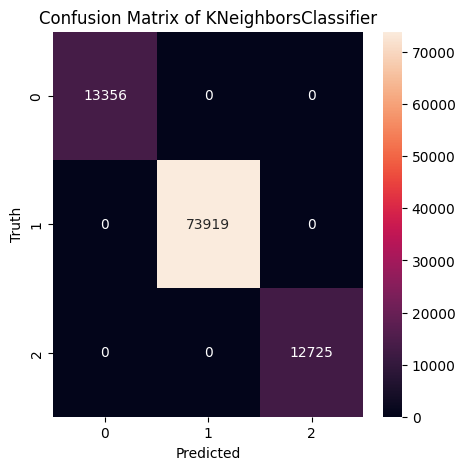



---		SVC		---

	Prediction time: 0.3169 seconds
	Accuracy score:	 0.9999

              precision    recall  f1-score   support

        Weak       1.00      1.00      1.00     13356
      Medium       1.00      1.00      1.00     73919
      Strong       1.00      1.00      1.00     12725

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000



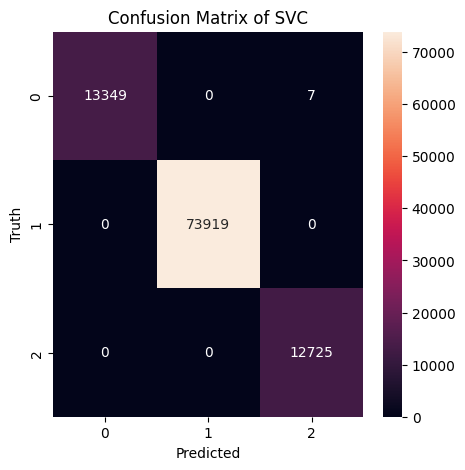



---		DecisionTreeClassifier		---

	Prediction time: 0.0051 seconds
	Accuracy score:	 1.0000

              precision    recall  f1-score   support

        Weak       1.00      1.00      1.00     13356
      Medium       1.00      1.00      1.00     73919
      Strong       1.00      1.00      1.00     12725

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000



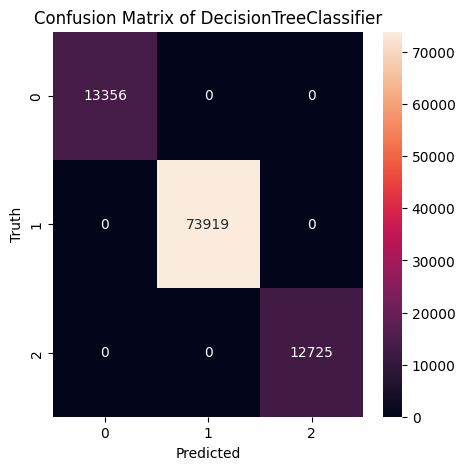



---		GaussianNB		---

	Prediction time: 0.0068 seconds
	Accuracy score:	 0.9995

              precision    recall  f1-score   support

        Weak       1.00      1.00      1.00     13356
      Medium       1.00      1.00      1.00     73919
      Strong       1.00      1.00      1.00     12725

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000



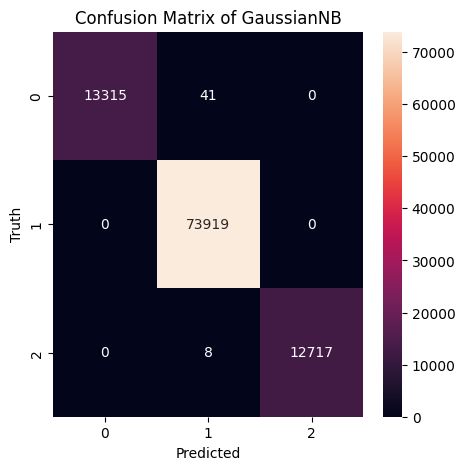



---		SGDClassifier		---

	Prediction time: 0.0058 seconds
	Accuracy score:	 0.9707

              precision    recall  f1-score   support

        Weak       1.00      1.00      1.00     13356
      Medium       1.00      0.96      0.98     73919
      Strong       0.81      1.00      0.90     12725

    accuracy                           0.97    100000
   macro avg       0.94      0.99      0.96    100000
weighted avg       0.98      0.97      0.97    100000



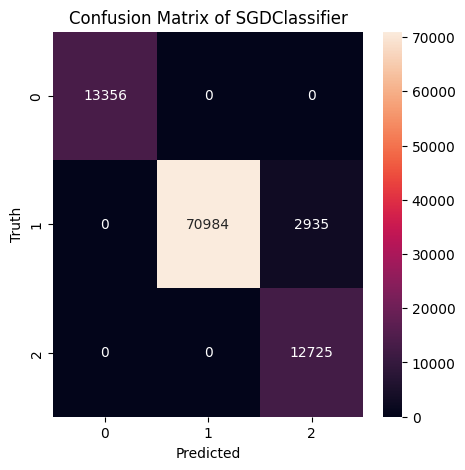

In [78]:
# Fit each classifier, make predictions, and evaluate performance
for clf in clfs:

    print("\n")
    print(f"---\t\t{clf.__class__.__name__}\t\t---\n")

    tic = time.perf_counter()
    predictions = clf.predict(xts)
    toc = time.perf_counter()
    print(f"\tPrediction time: {toc-tic:.4f} seconds")

    print(f"\tAccuracy score:\t {accuracy_score(yts, predictions):.4f}\n")
    print(classification_report(yts, predictions, target_names=["Weak", "Medium", "Strong"]))
    plot_confusion_matrix(yts, predictions, clf.__class__.__name__)
    

#### Test digits, symbols, upper

In [79]:
# Extract features
pass_length_train = data_shuffled["password"].str.len().head(N_TRAIN).values
digits_train = (data_shuffled["password"].head(N_TRAIN).apply(lambda x: len([c for c in x if c.isdigit()])).values)
symbols_train = (data_shuffled["password"].head(N_TRAIN).apply(lambda x: len([c for c in x if not c.isalnum()])).values)
upper_train = (data_shuffled["password"].head(N_TRAIN).apply(lambda x: len([c for c in x if c.isupper()])).values)
lower_train = (data_shuffled["password"].head(N_TRAIN).apply(lambda x: len([c for c in x if c.islower()])).values)
unique_chars_train = data_shuffled["password"].head(N_TRAIN).apply(lambda x: len(set(x))).values

pass_length_test = data_shuffled["password"].str.len().tail(N_TEST).values
digits_test = (data_shuffled["password"].tail(N_TEST).apply(lambda x: len([c for c in x if c.isdigit()])).values)
symbols_test = (data_shuffled["password"].tail(N_TEST).apply(lambda x: len([c for c in x if not c.isalnum()])).values)
upper_test = (data_shuffled["password"].tail(N_TEST).apply(lambda x: len([c for c in x if c.isupper()])).values)
lower_test = (data_shuffled["password"].tail(N_TEST).apply(lambda x: len([c for c in x if c.islower()])).values)
unique_chars_test = data_shuffled["password"].tail(N_TEST).apply(lambda x: len(set(x))).values

# Normalize features by password length (avoid division by zero)
digits_train_norm = digits_train / np.where(pass_length_train == 0, 1, pass_length_train)
symbols_train_norm = symbols_train / np.where(pass_length_train == 0, 1, pass_length_train)
upper_train_norm = upper_train / np.where(pass_length_train == 0, 1, pass_length_train)
lower_train_norm = lower_train / np.where(pass_length_train == 0, 1, pass_length_train)
unique_ratio_train = unique_chars_train / np.where(pass_length_train == 0, 1, pass_length_train)

digits_test_norm = digits_test / np.where(pass_length_test == 0, 1, pass_length_test)
symbols_test_norm = symbols_test / np.where(pass_length_test == 0, 1, pass_length_test)
upper_test_norm = upper_test /  np.where(pass_length_test == 0, 1, pass_length_test)
lower_test_norm = lower_test /  np.where(pass_length_test == 0, 1, pass_length_test)
unique_ratio_test = unique_chars_test / np.where(pass_length_test == 0, 1, pass_length_test)

# Split the dataset into features and target variable
xtr = np.array([digits_train_norm, symbols_train_norm, upper_train_norm, lower_train_norm, unique_chars_train]).T
ytr = data_shuffled["strength"].head(N_TRAIN).values

xts = np.array([digits_test_norm, symbols_test_norm, upper_test_norm, lower_test_norm, unique_chars_test]).T
yts = data_shuffled["strength"].tail(N_TEST).values

for clf in clfs:

    print("\n")
    print(f"---\t\t{clf.__class__.__name__}\t\t---\n")
    tic = time.perf_counter()
    clf.fit(xtr, ytr)
    toc = time.perf_counter()
    print(f"\tTraining time:\t {toc-tic:.4f} seconds")



---		KNeighborsClassifier		---

	Training time:	 0.0020 seconds


---		SVC		---

	Training time:	 0.0114 seconds


---		DecisionTreeClassifier		---

	Training time:	 0.0014 seconds


---		GaussianNB		---

	Training time:	 0.0010 seconds


---		SGDClassifier		---

	Training time:	 0.0110 seconds




---		KNeighborsClassifier		---

	Prediction time: 5.4923 seconds
	Accuracy score:	 0.9537

              precision    recall  f1-score   support

        Weak       0.85      0.95      0.89     13356
      Medium       0.97      0.96      0.97     73919
      Strong       0.97      0.89      0.93     12725

    accuracy                           0.95    100000
   macro avg       0.93      0.94      0.93    100000
weighted avg       0.96      0.95      0.95    100000



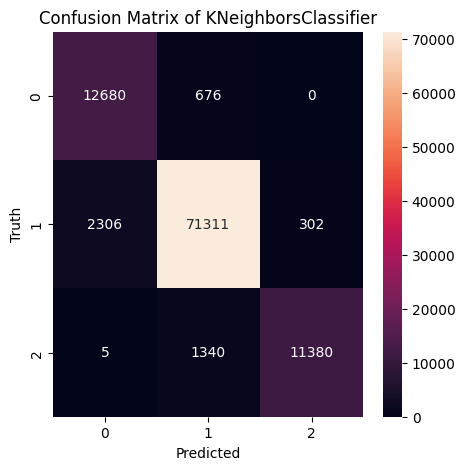



---		SVC		---

	Prediction time: 3.0713 seconds
	Accuracy score:	 0.8688

              precision    recall  f1-score   support

        Weak       0.69      0.30      0.42     13356
      Medium       0.87      0.97      0.92     73919
      Strong       0.98      0.86      0.92     12725

    accuracy                           0.87    100000
   macro avg       0.85      0.71      0.75    100000
weighted avg       0.86      0.87      0.85    100000



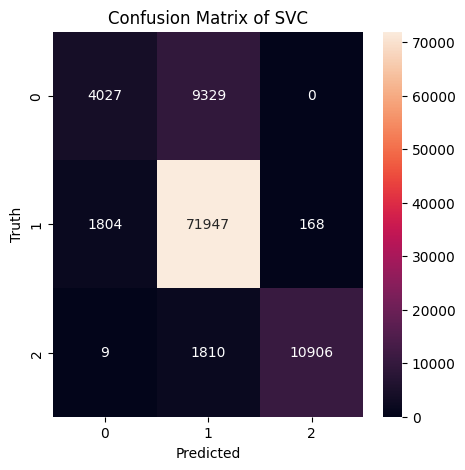



---		DecisionTreeClassifier		---

	Prediction time: 0.0068 seconds
	Accuracy score:	 0.8602

              precision    recall  f1-score   support

        Weak       0.42      0.01      0.03     13356
      Medium       0.85      0.99      0.91     73919
      Strong       0.96      1.00      0.98     12725

    accuracy                           0.86    100000
   macro avg       0.74      0.67      0.64    100000
weighted avg       0.80      0.86      0.80    100000



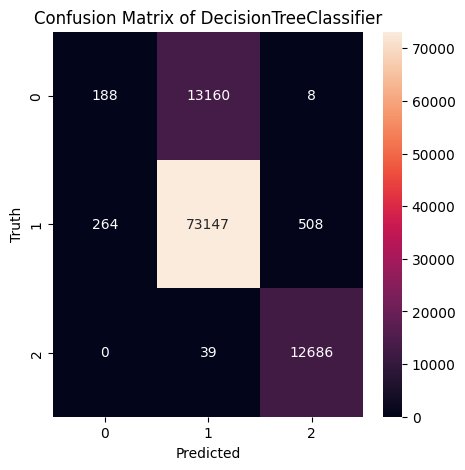



---		GaussianNB		---

	Prediction time: 0.0184 seconds
	Accuracy score:	 0.8549

              precision    recall  f1-score   support

        Weak       0.65      0.16      0.26     13356
      Medium       0.86      0.97      0.91     73919
      Strong       0.88      0.93      0.90     12725

    accuracy                           0.85    100000
   macro avg       0.80      0.69      0.69    100000
weighted avg       0.83      0.85      0.82    100000



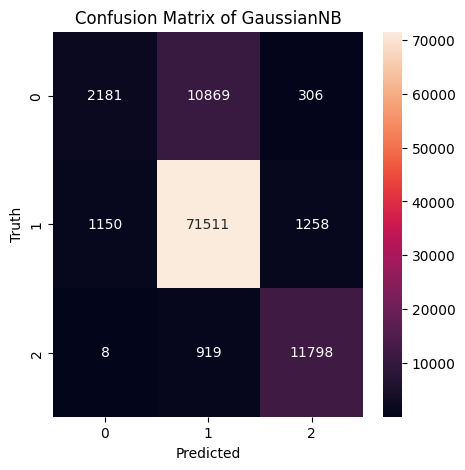



---		SGDClassifier		---

	Prediction time: 0.0055 seconds
	Accuracy score:	 0.8579

              precision    recall  f1-score   support

        Weak       0.60      0.22      0.32     13356
      Medium       0.86      0.97      0.91     73919
      Strong       0.98      0.87      0.92     12725

    accuracy                           0.86    100000
   macro avg       0.81      0.69      0.72    100000
weighted avg       0.84      0.86      0.83    100000



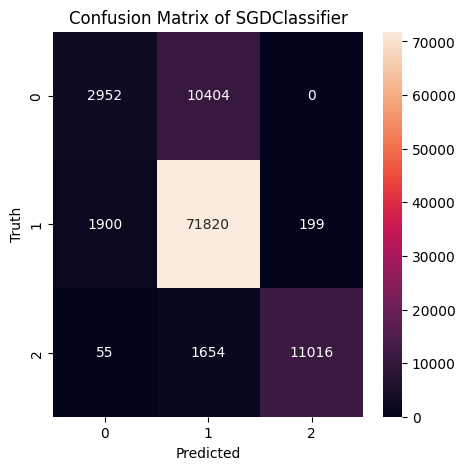

In [80]:
# Fit each classifier, make predictions, and evaluate performance
for clf in clfs:

    print("\n")
    print(f"---\t\t{clf.__class__.__name__}\t\t---\n")
    tic = time.perf_counter()
    predictions = clf.predict(xts)
    toc = time.perf_counter()
    print(f"\tPrediction time: {toc-tic:.4f} seconds")

      # If regressor, convert predictions to int class labels
    if hasattr(clf, "predict") and "Regressor" in clf.__class__.__name__:
        predictions = np.round(predictions).astype(int)

    print(f"\tAccuracy score:\t {accuracy_score(yts, predictions):.4f}\n")
    print(classification_report(yts, predictions, target_names=["Weak", "Medium", "Strong"], zero_division=0))
    plot_confusion_matrix(yts, predictions, clf.__class__.__name__)



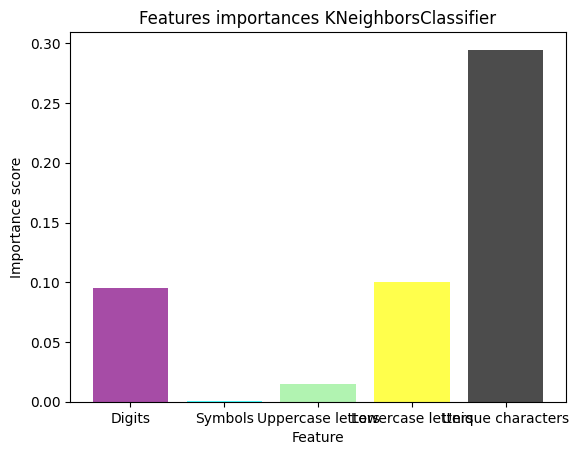

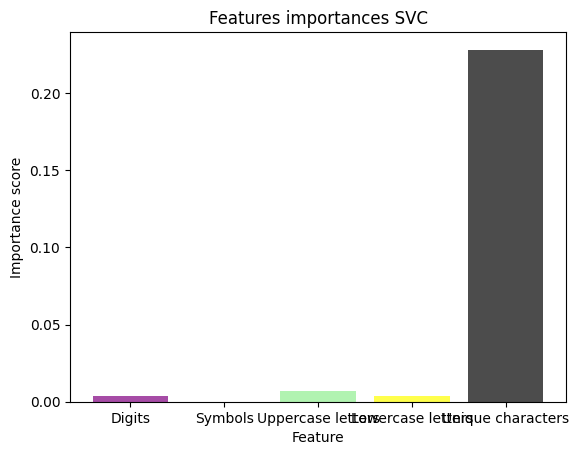

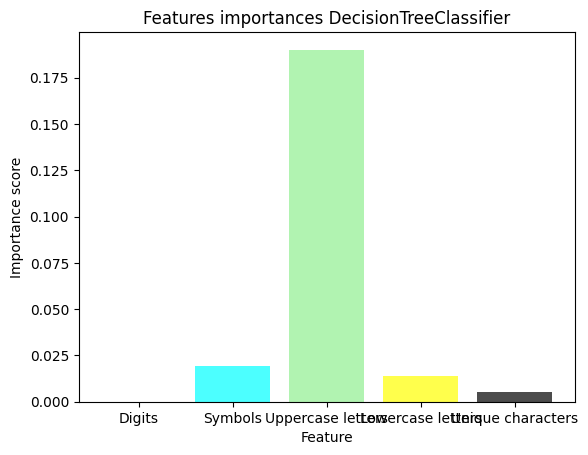

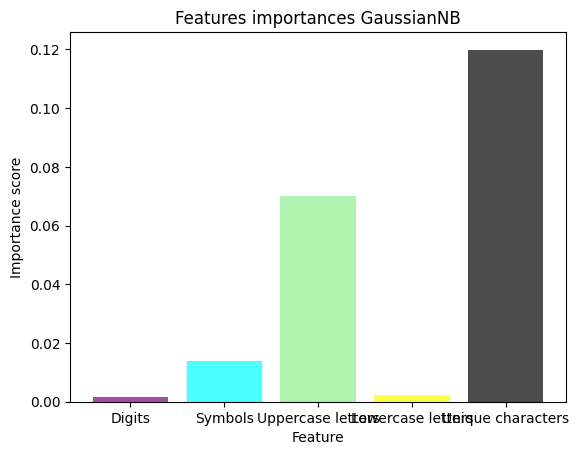

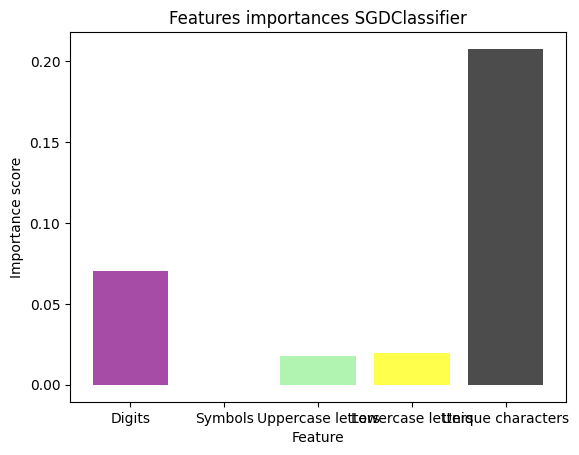

In [81]:
# Calculate and plot feature importances for each classifier
for clf in clfs:
    results = permutation_importance(clf, xts, yts, n_repeats=10, random_state=0)
    importances = results.importances_mean
    
    feature_names=["Digits", "Symbols", "Uppercase letters", "Lowercase letters", "Unique characters"]
    feature_importance_histogram(importances, feature_names, title=f"Features importances {clf.__class__.__name__}")